In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

In [2]:
#### Load Data & Overview

In [3]:
data_wine=load_wine()
data_wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [4]:
df_wine=pd.DataFrame(data_wine.data, columns=data_wine.feature_names)
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [5]:
df_wine['target']=data_wine.target
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [7]:
df_wine.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [8]:
df_wine.describe().T[['min','max']]

,min,max
alcohol,11.03,14.83
malic_acid,0.74,5.80
ash,1.36,3.23
alcalinity_of_ash,10.60,30.00
magnesium,70.00,162.00
total_phenols,0.98,3.88
flavanoids,0.34,5.08
nonflavanoid_phenols,0.13,0.66
proanthocyanins,0.41,3.58
color_intensity,1.28,13.00


In [9]:
df_wine.isna().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


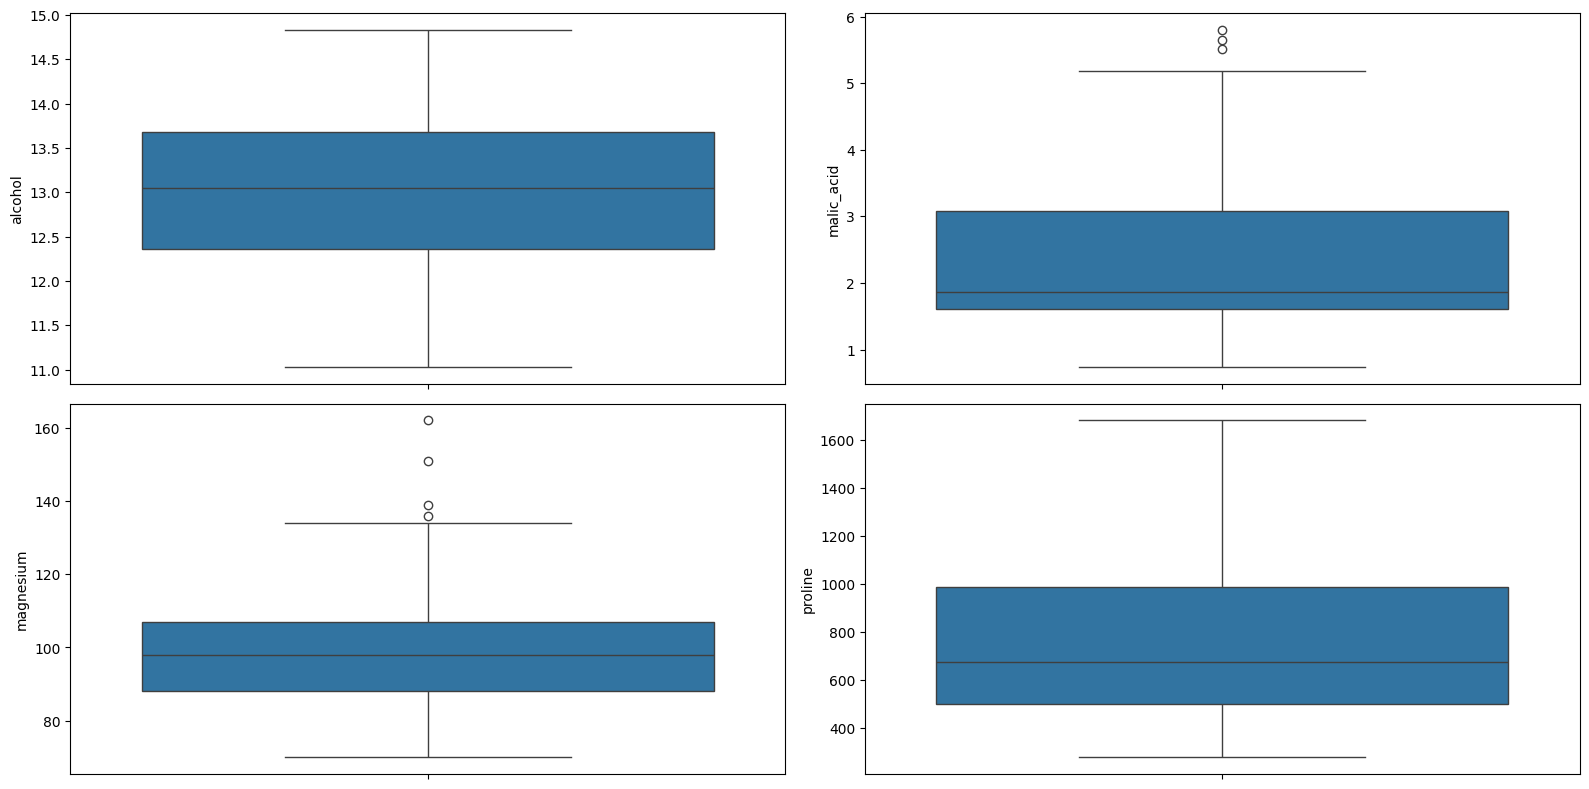

In [10]:
features= ['alcohol', 'malic_acid','magnesium','proline']
plt.figure(figsize=(16,8))
for index,col in enumerate(features,1):
    plt.subplot(2,2,index)
    sns.boxplot(df_wine[col])
plt.tight_layout()
plt.show()

<Axes: >

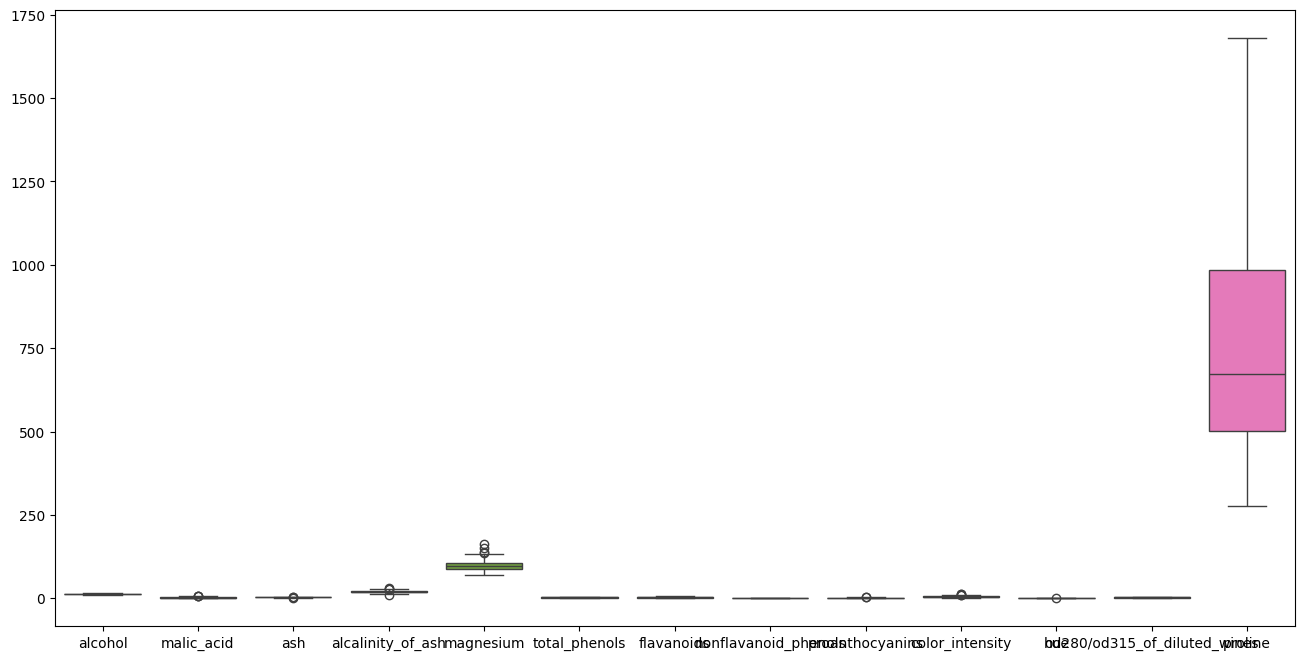

In [11]:
plt.figure(figsize=(16,8))
sns.boxplot(data=df_wine.drop('target',axis=1))



In [12]:
sample1=df_wine.iloc[0][:-1]
sample2=df_wine.iloc[1][:-1]

distance=np.linalg.norm(sample1-sample2)
print(f'Distance is {distance}')

Distance is 31.265012394048398


In [13]:
difference=abs(sample1-sample2)
difference.sort_values(ascending=False)


,0
magnesium,27.00
proline,15.00
alcalinity_of_ash,4.40
color_intensity,1.26
alcohol,1.03
proanthocyanins,1.01
od280/od315_of_diluted_wines,0.52
flavanoids,0.30
ash,0.29
total_phenols,0.15


Standardization
z=(x-xmean)/std

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df_wine.drop('target', axis=1))

df_wine_scaled = pd.DataFrame(
    scaled,
    columns=df_wine.columns[:-1]
)

df_wine_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [15]:
df_wine_scaled.mean().round(2)

,0
alcohol,0.0
malic_acid,0.0
ash,-0.0
alcalinity_of_ash,-0.0
magnesium,-0.0
total_phenols,-0.0
flavanoids,0.0
nonflavanoid_phenols,-0.0
proanthocyanins,-0.0
color_intensity,-0.0


In [16]:
df_wine_scaled.std().round(2)

,0
alcohol,1.0
malic_acid,1.0
ash,1.0
alcalinity_of_ash,1.0
magnesium,1.0
total_phenols,1.0
flavanoids,1.0
nonflavanoid_phenols,1.0
proanthocyanins,1.0
color_intensity,1.0


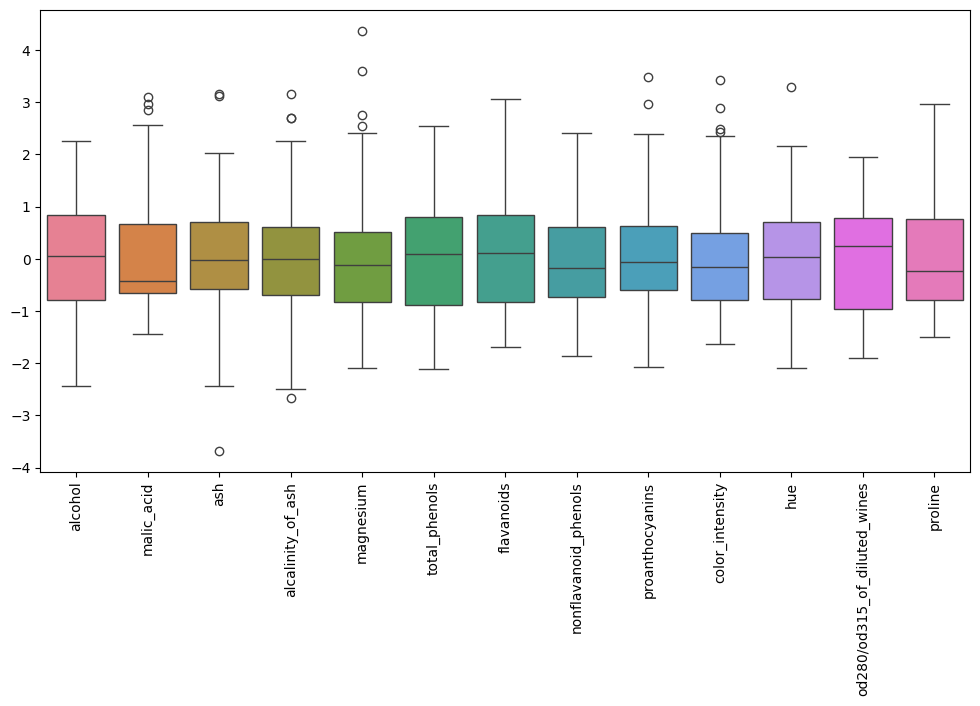

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_wine_scaled)
plt.xticks(rotation=90)
plt.show()

In [18]:
sample1=df_wine_scaled.iloc[0][:]
sample2=df_wine_scaled.iloc[1][:]

distance=np.linalg.norm(sample1-sample2)
print(f'Distance is scaled data{distance}')

Distance is scaled data3.497535222046172


In [19]:
difference=abs(sample1-sample2)
difference.sort_values(ascending=False)

,0
magnesium,1.895760
proanthocyanins,1.769605
alcalinity_of_ash,1.321254
alcohol,1.272323
ash,1.060049
od280/od315_of_diluted_wines,0.734470
color_intensity,0.545038
flavanoids,0.301190
total_phenols,0.240350
nonflavanoid_phenols,0.161156


In [20]:
from sklearn.preprocessing import MinMaxScaler
mms= MinMaxScaler()

normalized = mms.fit_transform(df_wine.drop('target', axis=1))
df_wine_normalized= pd.DataFrame(normalized, columns=df_wine.columns[:-1])
df_wine_normalized.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963


In [21]:
df_wine_normalized.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,0.518584,0.213639,0.0,0.350658,0.531579,0.696711,1.0
malic_acid,178.0,0.315484,0.220780,0.0,0.170455,0.222332,0.462945,1.0
ash,178.0,0.538244,0.146708,0.0,0.454545,0.534759,0.640374,1.0
alcalinity_of_ash,178.0,0.458502,0.172142,0.0,0.340206,0.458763,0.561856,1.0
magnesium,178.0,0.323278,0.155244,0.0,0.195652,0.304348,0.402174,1.0
total_phenols,178.0,0.453487,0.215811,0.0,0.262931,0.474138,0.627586,1.0
flavanoids,178.0,0.356386,0.210730,0.0,0.182489,0.378692,0.534810,1.0
nonflavanoid_phenols,178.0,0.437460,0.234818,0.0,0.264151,0.396226,0.580189,1.0
proanthocyanins,178.0,0.372523,0.180555,0.0,0.264984,0.361199,0.485804,1.0
color_intensity,178.0,0.322363,0.197806,0.0,0.165529,0.290956,0.419795,1.0


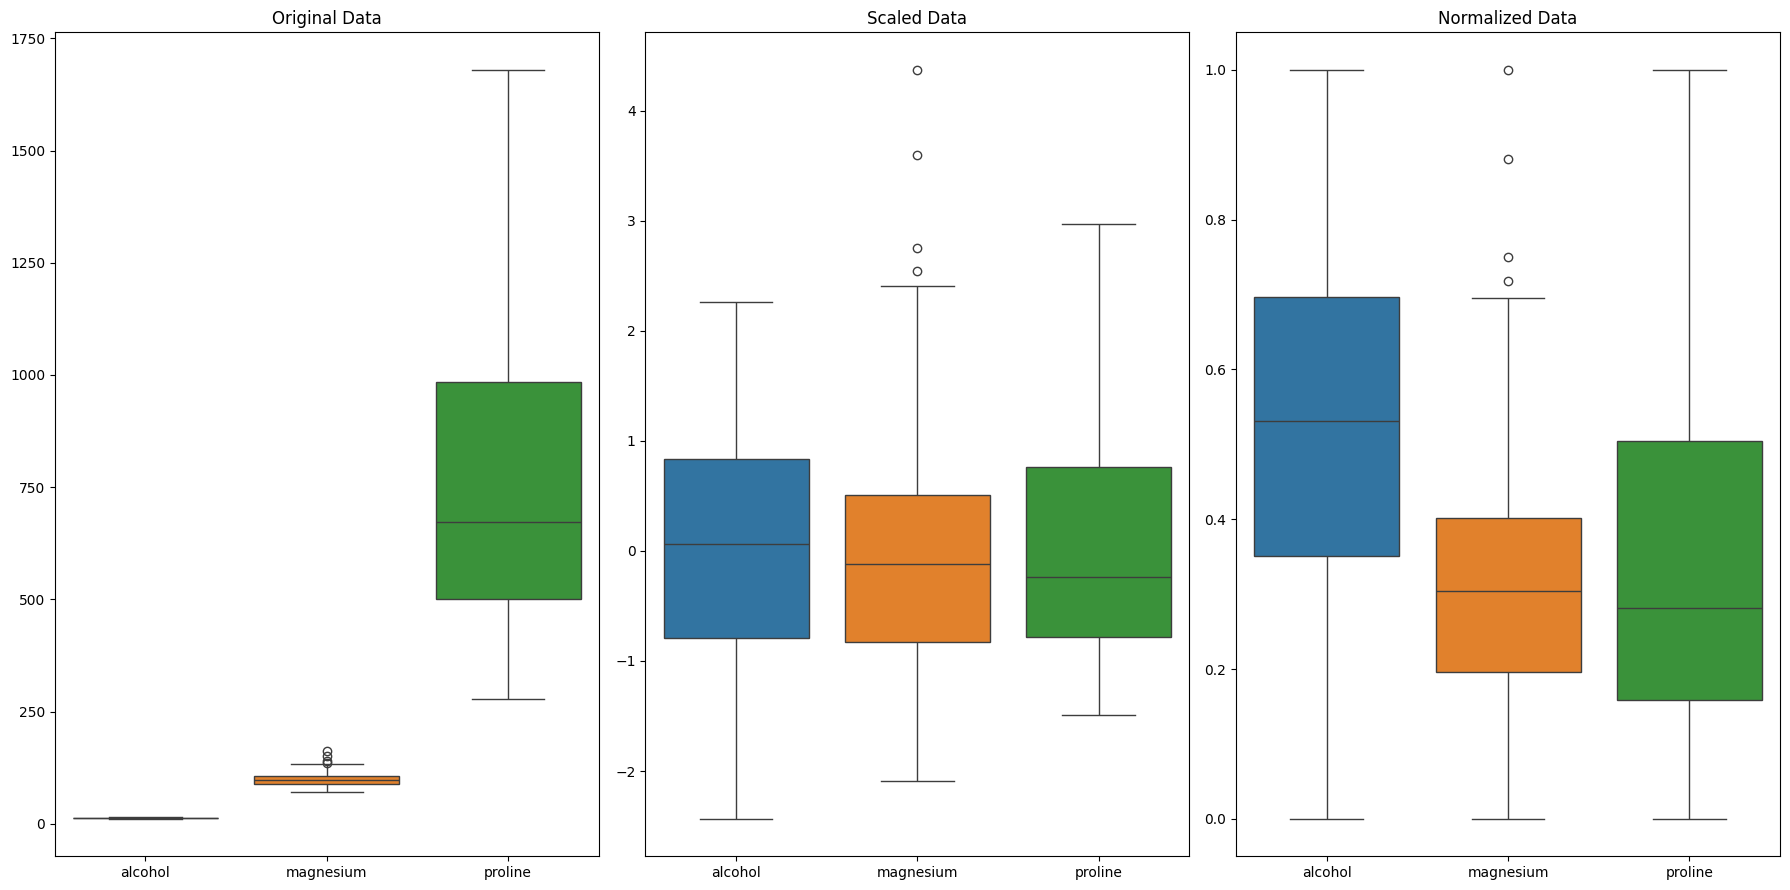

In [22]:
fig,ax= plt.subplots(1,3,figsize=(18,9))
sns.boxplot(data=df_wine[['alcohol','magnesium','proline']],ax=ax[0])
ax[0].set_title('Original Data')

sns.boxplot(data=df_wine_scaled[['alcohol','magnesium','proline']],ax=ax[1])
ax[1].set_title('Scaled Data')

sns.boxplot(data=df_wine_normalized[['alcohol','magnesium','proline']],ax=ax[2])
ax[2].set_title('Normalized Data')

plt.tight_layout()
plt.show()

In [23]:
from sklearn.preprocessing import RobustScaler

robustScaler = RobustScaler()

df_wine_robustscaled = pd.DataFrame(
    robustScaler.fit_transform(df_wine.drop('target', axis=1)),
    columns=df_wine.columns[:-1]
)

df_wine_robustscaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050
1,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090
2,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728
3,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603
4,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935


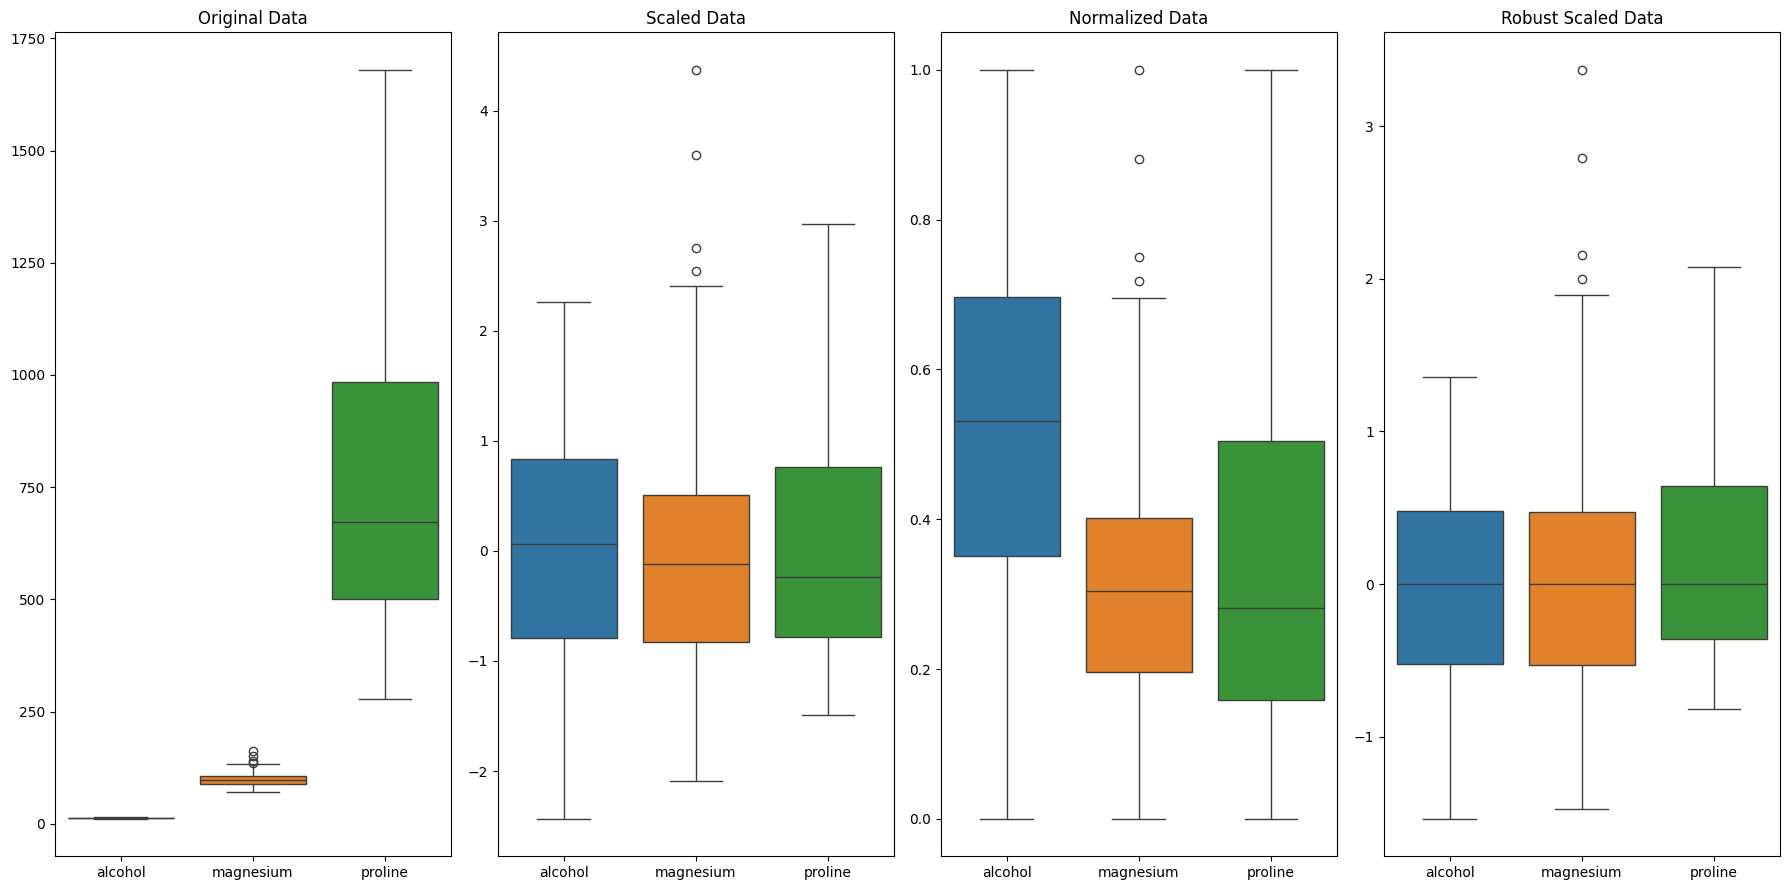

In [24]:
fig,ax= plt.subplots(1,4,figsize=(18,9))
sns.boxplot(data=df_wine[['alcohol','magnesium','proline']],ax=ax[0])
ax[0].set_title('Original Data')

sns.boxplot(data=df_wine_scaled[['alcohol','magnesium','proline']],ax=ax[1])
ax[1].set_title('Scaled Data')

sns.boxplot(data=df_wine_normalized[['alcohol','magnesium','proline']],ax=ax[2])
ax[2].set_title('Normalized Data')

sns.boxplot(data=df_wine_robustscaled[['alcohol','magnesium','proline']],ax=ax[3])
ax[3].set_title('Robust Scaled Data')

plt.tight_layout()
plt.show()

In [25]:
import scipy.stats as stat
import pylab


In [26]:
def plot_data(df,feature):
  plt.figure(figsize=(12,6))
  plt.subplot(1,2,1)
  df[feature].hist()
  plt.subplot(1,2,2)
  stat.probplot(df[feature],dist='norm',plot=pylab)
  plt.title("Q-Q Plot"+feature)
  plt.show()

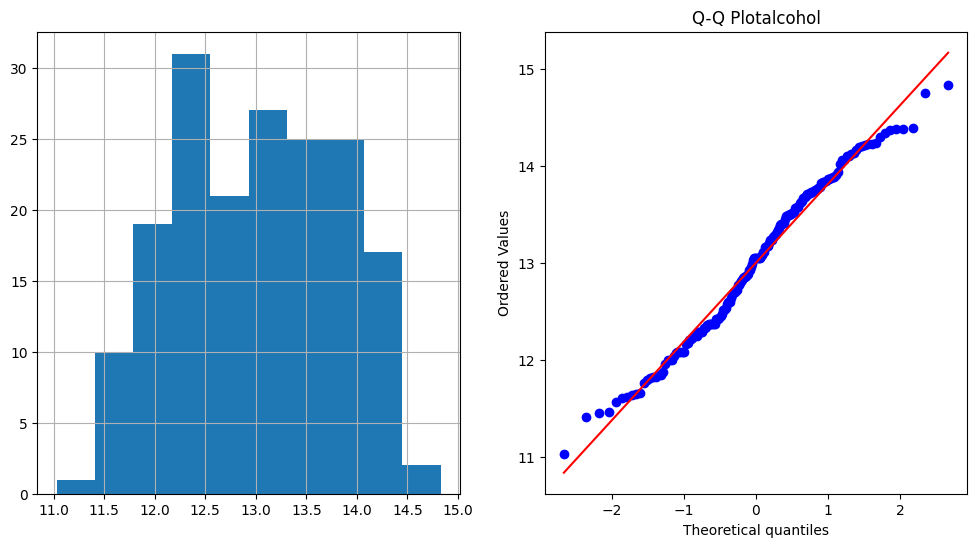

In [27]:
plot_data(df_wine,'alcohol')

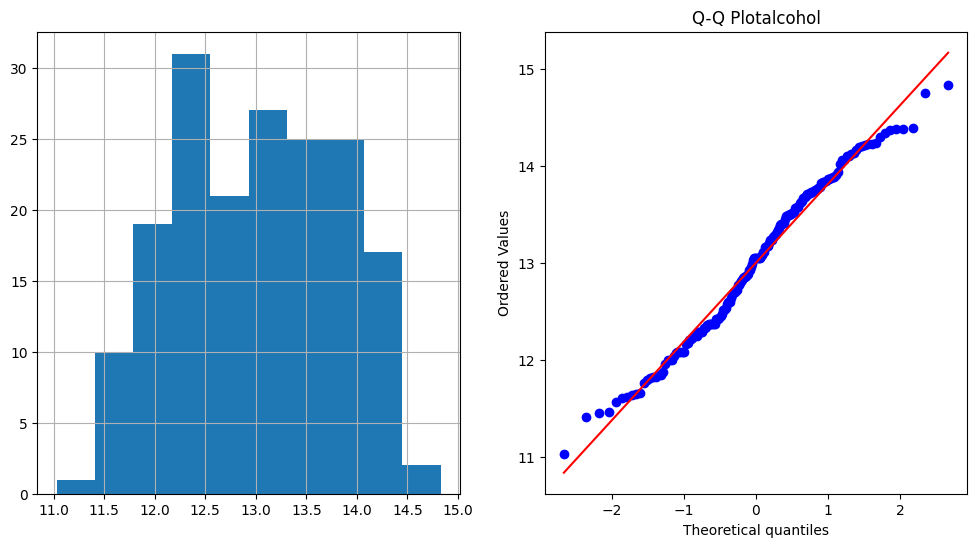

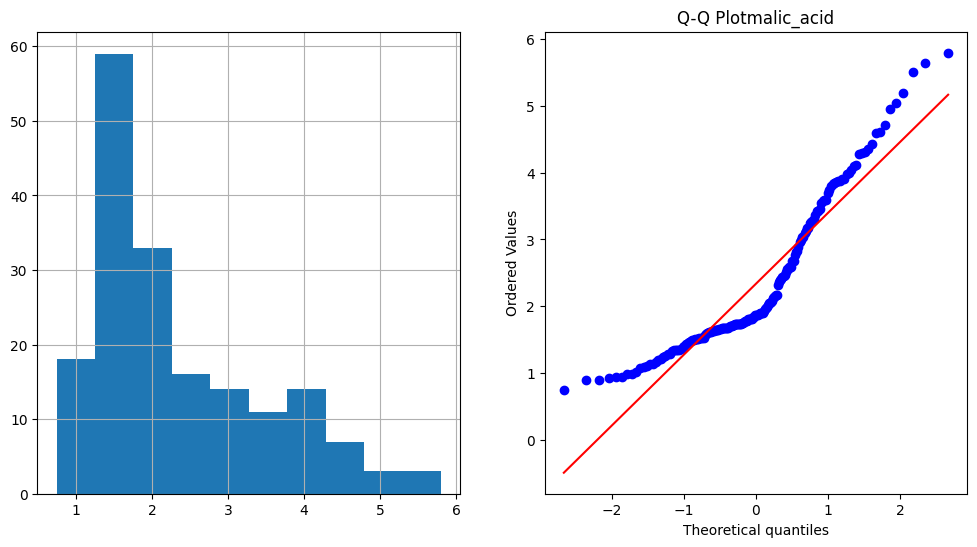

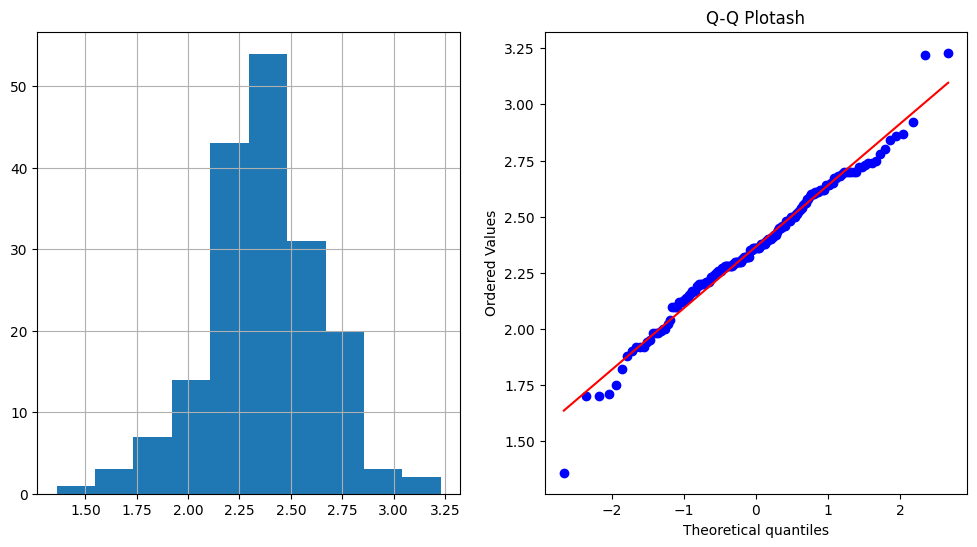

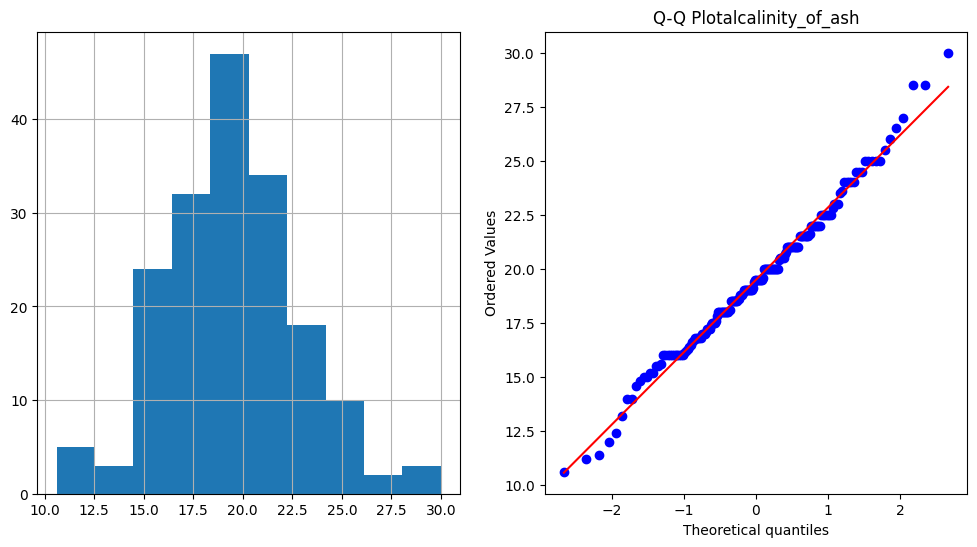

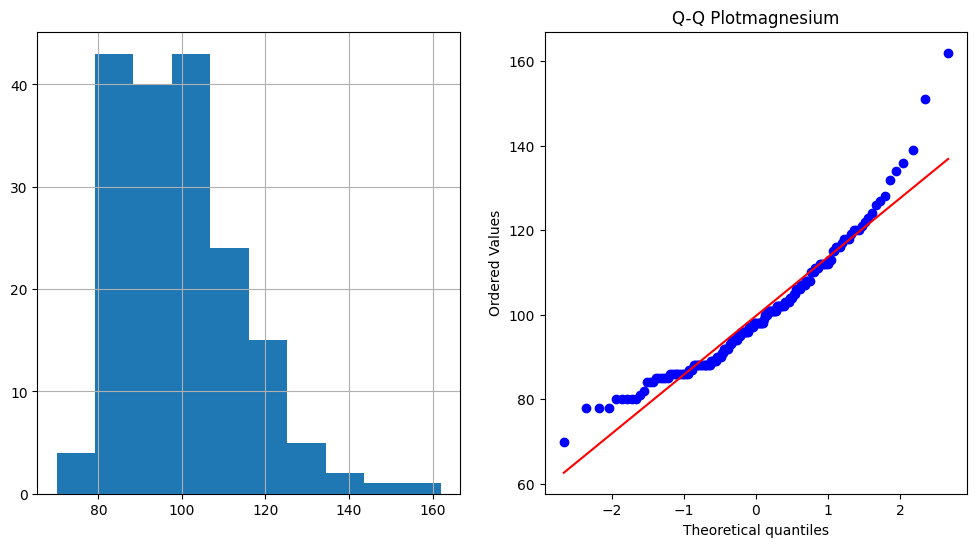

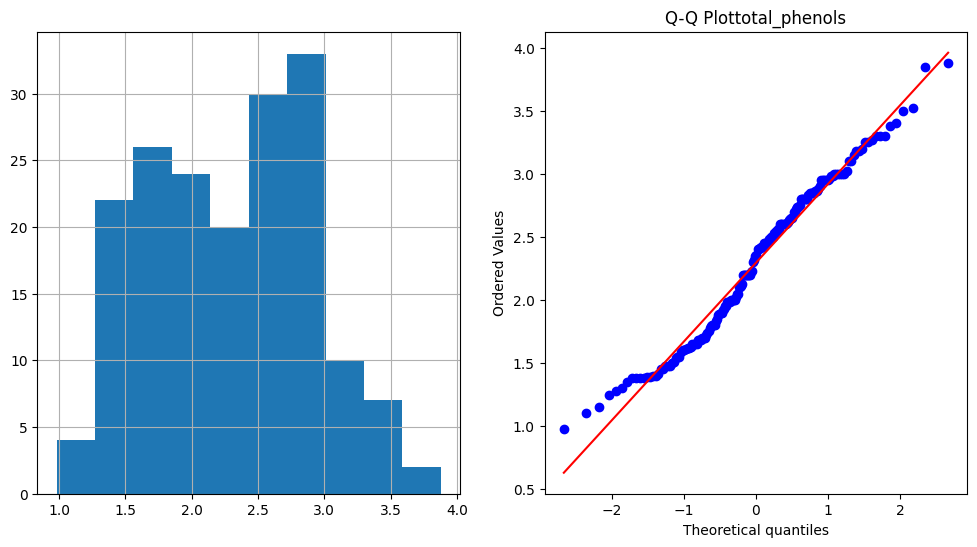

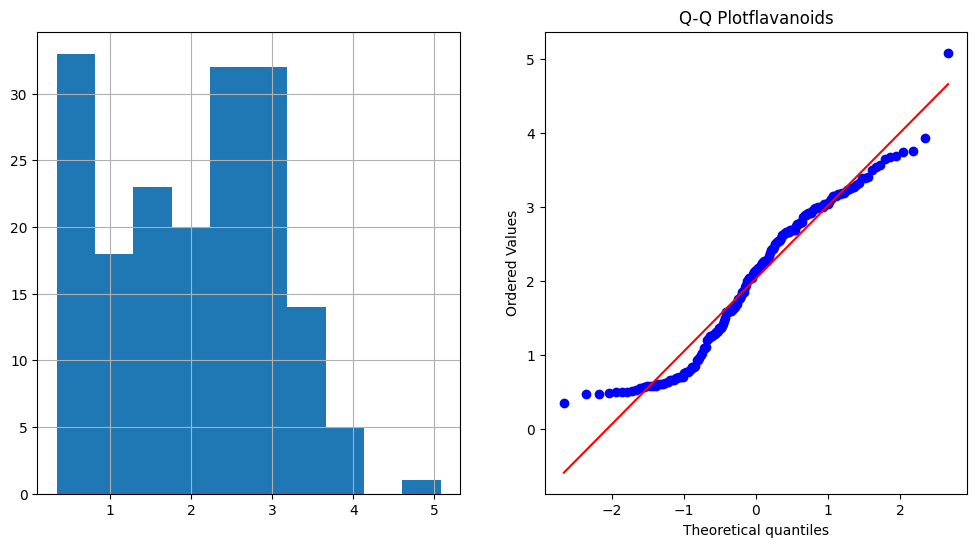

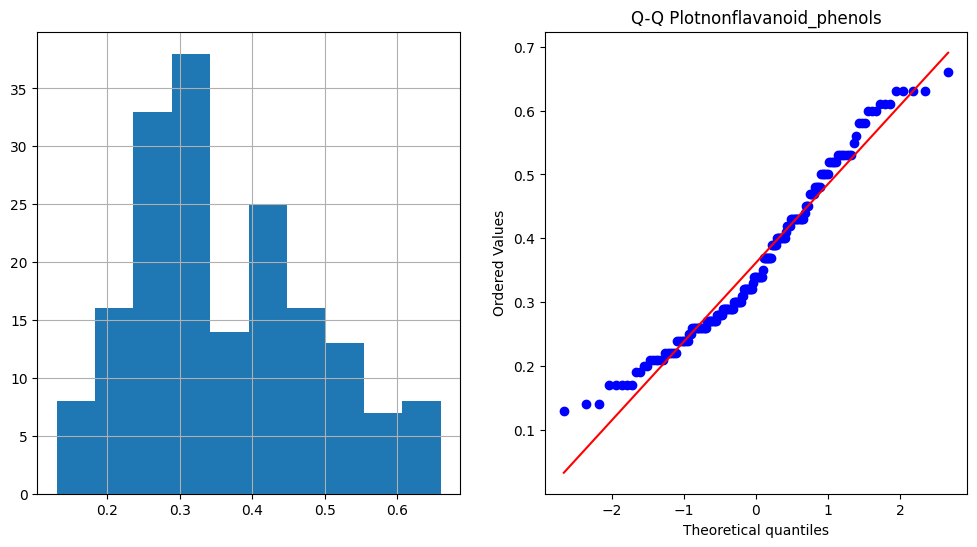

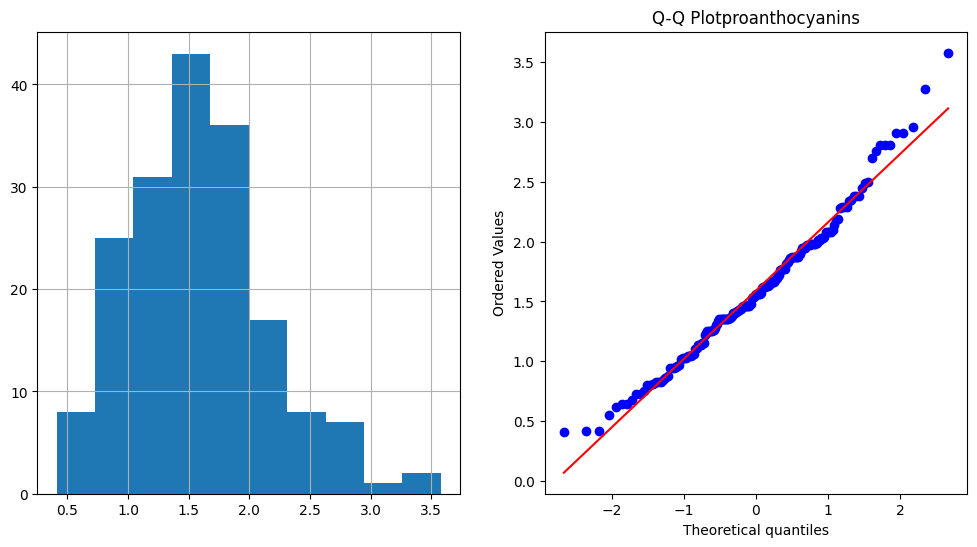

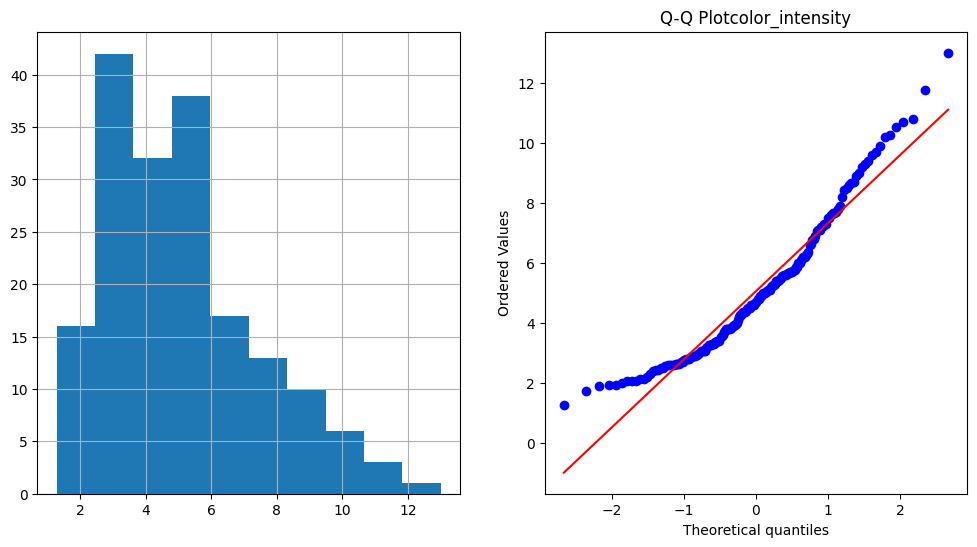

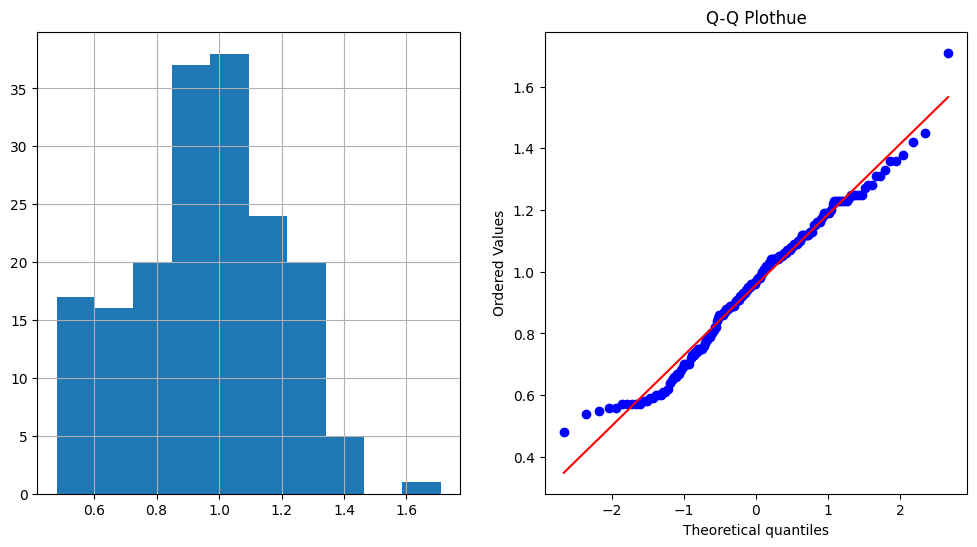

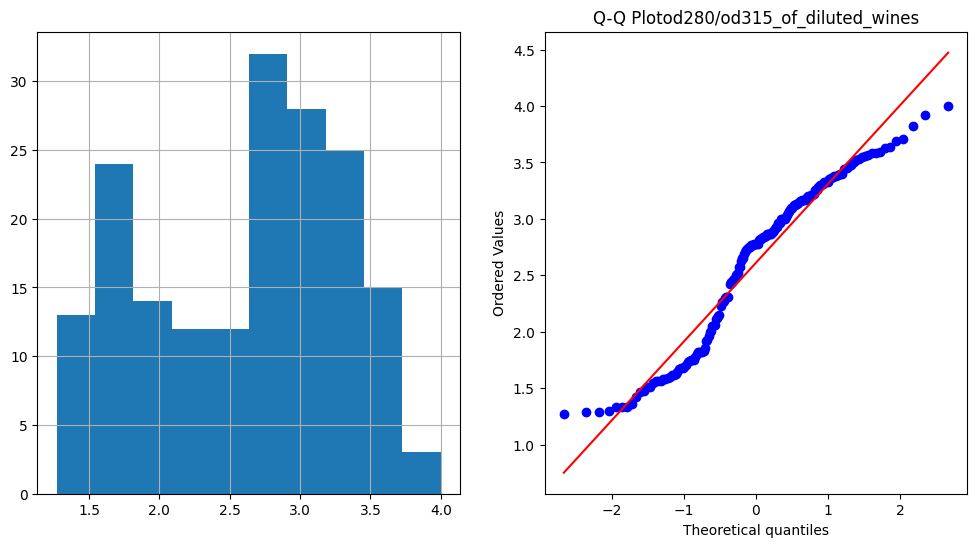

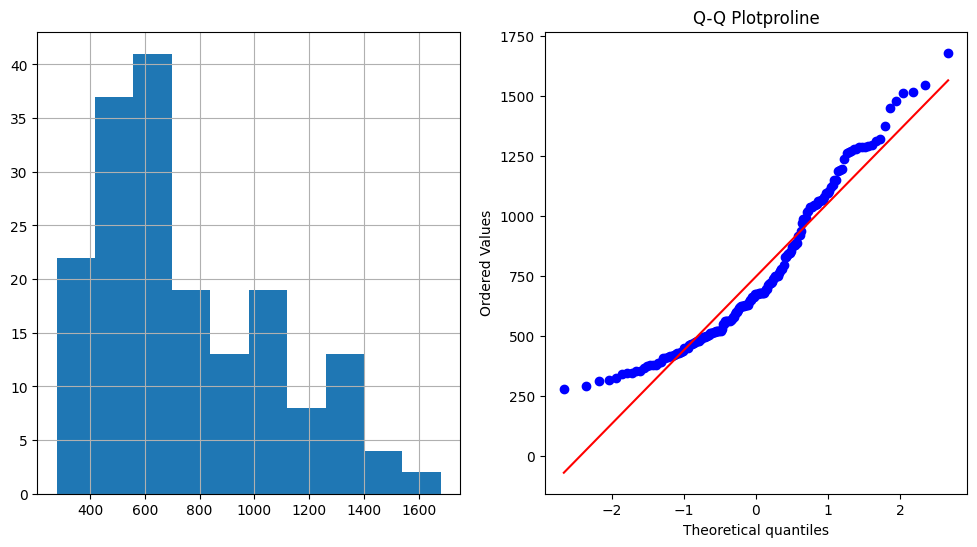

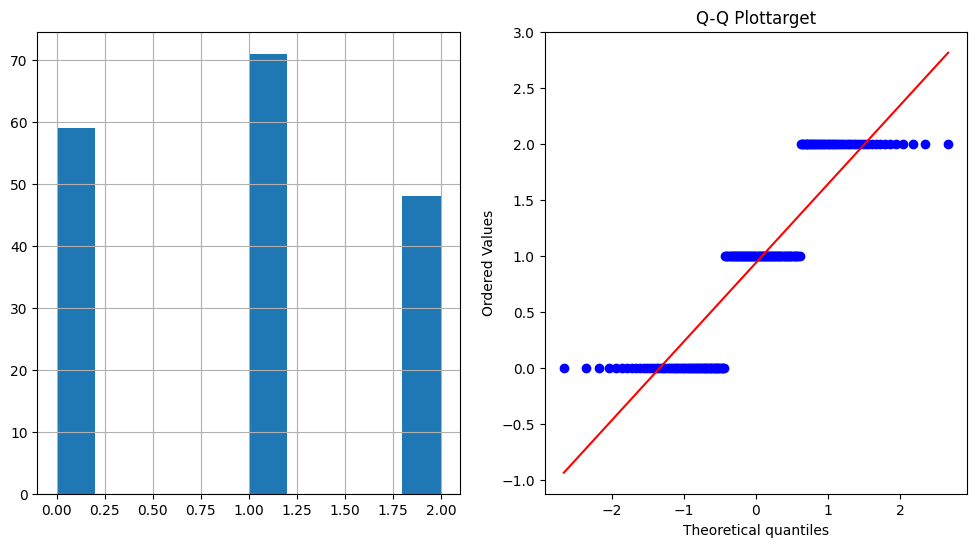

In [28]:
for column in df_wine.columns:
  plot_data(df_wine, column)

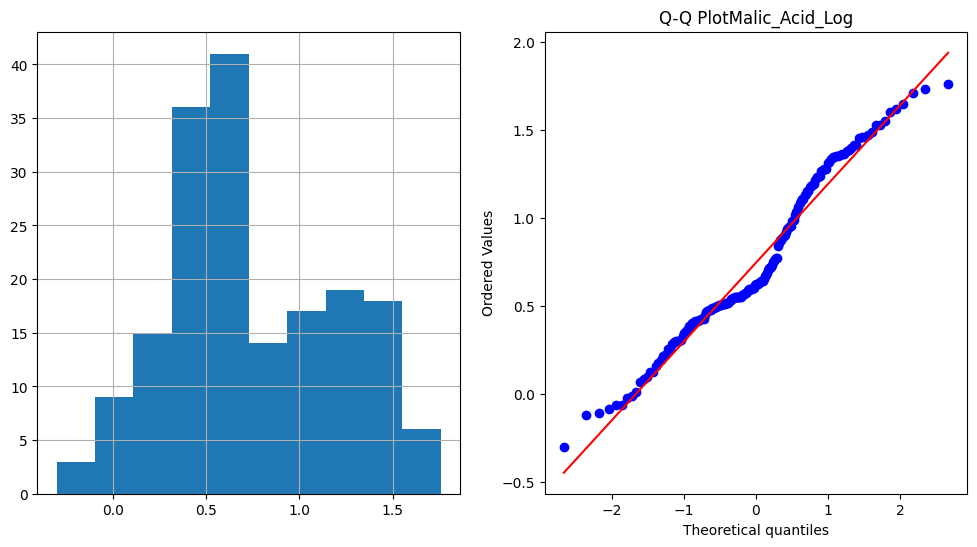

In [29]:
#Logarithm Transformation

df_wine["Malic_Acid_Log"]=np.log(df_wine['malic_acid'])
plot_data(df_wine,'Malic_Acid_Log')

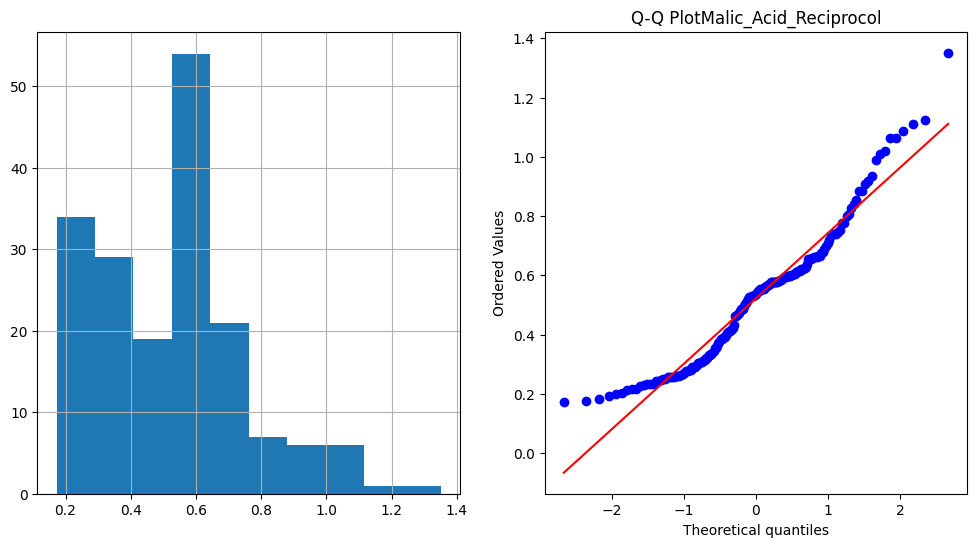

In [30]:
#Reciprocal Transformation

df_wine["Malic_Acid_Reciprocol"]=1/df_wine.malic_acid
plot_data(df_wine,'Malic_Acid_Reciprocol')

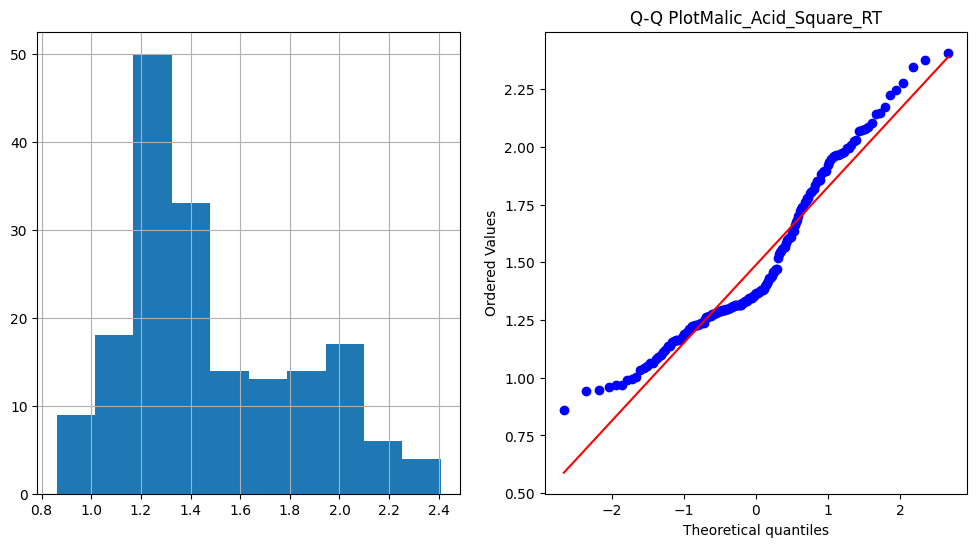

In [34]:
#Square root Transformation


df_wine['Malic_Acid_Square_RT'] = df_wine['malic_acid'] ** (1/2)

# or equivalently
# df_wine['Malic_Acid_Square_RT'] = np.sqrt(df_wine['malic_acid'])

plot_data(df_wine, 'Malic_Acid_Square_RT')

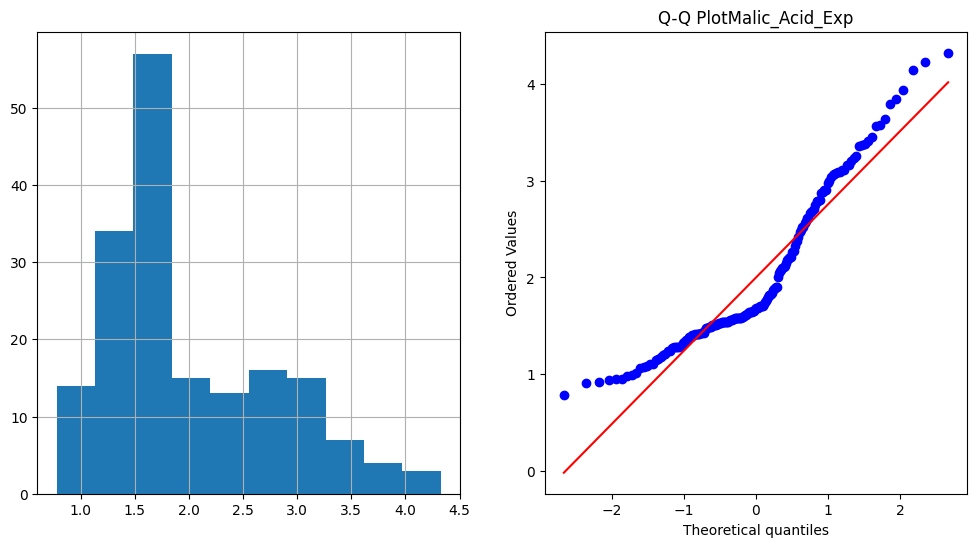

In [35]:
df_wine['Malic_Acid_Exp']=df_wine.malic_acid**(1/1.2)
plot_data(df_wine,'Malic_Acid_Exp')

In [36]:
#BoxCox

df_wine['Malic_Acid_BoxCox'],parameter=stat.boxcox(df_wine['malic_acid'])

In [37]:
print('Value of parameter',parameter)

Value of parameter -0.2777553257851528


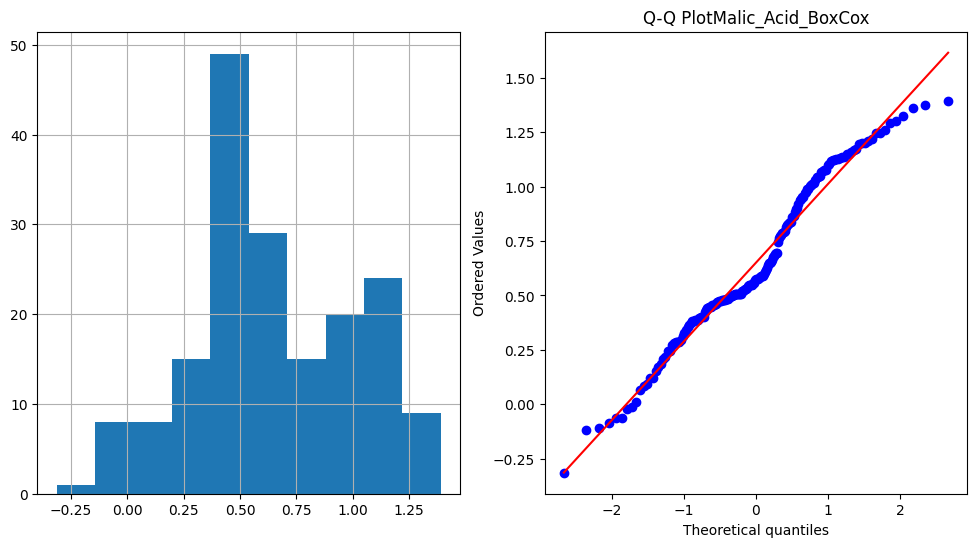

In [38]:
plot_data(df_wine,'Malic_Acid_BoxCox')